<a href="https://colab.research.google.com/github/Smox656/ImageClassifier/blob/main/CNNs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
mkdir -p ~/.kaggle && echo KGAT_6950d31c0e05057481dc27867f380bc3 > ~/.kaggle/access_token && chmod 600 ~/.kaggle/access_token

In [5]:
!kaggle datasets download -d nikhilkushwaha2529/real-estate-with-image --unzip

Dataset URL: https://www.kaggle.com/datasets/nikhilkushwaha2529/real-estate-with-image
License(s): unknown
100% 658M/658M [00:06<00:00, 109MB/s] 



In [51]:
!ls /content/Real_estatewith_image/archive-2/socal2/socal_pics/

0.jpg	   11991.jpg  13981.jpg  2043.jpg  4033.jpg  6023.jpg  8013.jpg
10000.jpg  11992.jpg  13982.jpg  2044.jpg  4034.jpg  6024.jpg  8014.jpg
10001.jpg  11993.jpg  13983.jpg  2045.jpg  4035.jpg  6025.jpg  8015.jpg
10002.jpg  11994.jpg  13984.jpg  2046.jpg  4036.jpg  6026.jpg  8016.jpg
10003.jpg  11995.jpg  13985.jpg  2047.jpg  4037.jpg  6027.jpg  8017.jpg
10004.jpg  11996.jpg  13986.jpg  2048.jpg  4038.jpg  6028.jpg  8018.jpg
10005.jpg  11997.jpg  13987.jpg  2049.jpg  4039.jpg  6029.jpg  8019.jpg
10006.jpg  11998.jpg  13988.jpg  204.jpg   403.jpg   602.jpg   801.jpg
10007.jpg  11999.jpg  13989.jpg  2050.jpg  4040.jpg  6030.jpg  8020.jpg
10008.jpg  1199.jpg   1398.jpg	 2051.jpg  4041.jpg  6031.jpg  8021.jpg
10009.jpg  119.jpg    13990.jpg  2052.jpg  4042.jpg  6032.jpg  8022.jpg
1000.jpg   11.jpg     13991.jpg  2053.jpg  4043.jpg  6033.jpg  8023.jpg
10010.jpg  12000.jpg  13992.jpg  2054.jpg  4044.jpg  6034.jpg  8024.jpg
10011.jpg  12001.jpg  13993.jpg  2055.jpg  4045.jpg  6035.jpg  8025.

In [46]:
df = pd.read_csv('/content/Real_estatewith_image/archive-2/socal2.csv')
df.head()
df[df['price'] > 1000000]

,image_id,street,citi,n_citi,bed,bath,sqft,price
10,10,38833 Gorman Post Road,"Gorman, CA",129,3,2.1,4044,1350000
11,11,8072 Cuddy Valley Road,"Frazier Park, CA",122,5,5.1,6247,1499000
12,12,818 155th Street W,"Rosamond, CA",312,2,2.0,2466,1488000
14,14,230 Gaskell Road,"Rosamond, CA",312,1,1.0,1048,2000000
15,15,8072 Cuddy Valley Road,"Frazier Park, CA",122,5,5.1,6247,1499000
...,...,...,...,...,...,...,...,...
14787,14787,2461 Jamestown Court,"Oxnard, CA",261,4,3.0,2192,1795000
14788,14788,1370 Cuyama Road,"Ojai, CA",257,3,3.0,2490,1500000
14789,14789,14859 Telegraph Road,"Santa Paula, CA",338,7,5.1,5450,1595000
14790,14790,8205 Waters Road,"Moorpark, CA",227,2,1.0,1200,1995000


In [65]:

import torch
import torch as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
import timm
from PIL import Image

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

In [66]:
class PlayingCardDataset(Dataset):
  def __init__(self, csv_file, img_dir, transform=None):
    self.dataframe = pd.read_csv(csv_file)
    self.img_dir = img_dir


  def __len__(self):
    return len(self.dataframe)


  def __getitem__(self, idx):
    nom_img = str(self.dataframe['image_id'].iloc[idx])
    if not nom_img.endswith('jpg'):
      nom_img += '.jpg'

      chemin_img = os.path.join(self.img_dir, nom_img)
      image = Image.open(chemin_img).convert("RGB")

      prix = self.dataframe['price'].iloc[idx]

      if prix >= 1000000:
        label = 0
      elif prix < 400000:
        label = 1
      else :
        label = 2


    return image, label

  @property
  def classes(self):
    return self.dataframe.classes

In [67]:
dataset = PlayingCardDataset('/content/Real_estatewith_image/archive-2/socal2.csv',
                             '/content/Real_estatewith_image/archive-2/socal2/socal_pics', )

In [68]:
len(dataset)

15474

In [69]:
dataset[0]

(<PIL.Image.Image image mode=RGB size=350x350>, 1)

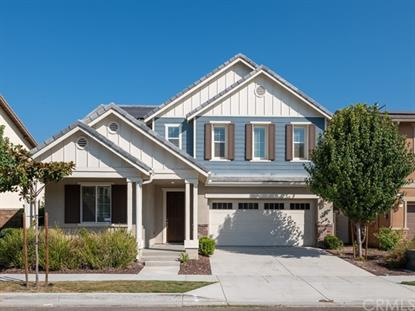

In [75]:
image, label = dataset[10100]
image
